In [11]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# Model 1: Risk Scorer (XGBoost regression on GPR)

Learns the Geopolitical Risk index from each country's structural features, then scores every country including those with no published GPR. Validated two ways, across unseen countries and forward in time.

**Input:** `data/processed/master_v1.csv` (features plus the GPR target).  
**Output:** `data/processed/risk_scores_v1.csv` and `data/processed/model_comparison.xlsx`.

In [2]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 220, 'savefig.bbox': 'tight',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#ECECEC', 'grid.linewidth': 0.7,
    'axes.axisbelow': True, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, TEAL, RED, GREEN, GREY = '#1F3864', '#2E75B6', '#2A9D8F', '#C0392B', '#5CB85C', '#BBBBBB'

M = pd.read_csv(str(ROOT / "data/processed/master_v1.csv"))
M.loc[M.iso3 == 'TWN', 'country'] = 'Taiwan'

drop = ['iso3','country','region','income_group','year','gpr']
features = [c for c in M.columns if c not in drop]
lab = M[M.gpr.notna()].copy()
lab['y'] = np.log1p(lab['gpr'])
X, y, grp = lab[features], lab['y'], lab['iso3']
print('train rows:', len(lab), '| features:', len(features), '| countries:', grp.nunique())

PARAMS = dict(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
              colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
              objective='reg:squarederror', random_state=42)

train rows: 440 | features: 68 | countries: 44


## 1. Cross-country generalization (GroupKFold)

Five folds split by country, so each country is scored by a model trained only on the others. This is the test that matters for the 203 countries with no official GPR. The model orders unseen countries at Spearman 0.81.

In [3]:
gkf = GroupKFold(n_splits=5)
oof = np.zeros(len(lab))
for tr, te in gkf.split(X, y, grp):
    mdl = xgb.XGBRegressor(**PARAMS).fit(X.iloc[tr], y.iloc[tr])
    oof[te] = mdl.predict(X.iloc[te])

oof_gpr = np.expm1(oof); true_gpr = lab['gpr'].values
rho = spearmanr(true_gpr, oof_gpr).statistic
mae_raw = mean_absolute_error(true_gpr, oof_gpr)
print('GroupKFold OOF | Spearman=%.3f  MAE=%.3f  (target mean %.3f)'
      % (rho, mae_raw, true_gpr.mean()))

GroupKFold OOF | Spearman=0.807  MAE=0.159  (target mean 0.282)


## 2. Forecasting the next year (expanding-window)

For each year from 2019 to 2024, train only on earlier years and forecast the next one, so no future data leaks.

In [4]:
MIN_TRAIN_YEARS = 4
years = sorted(lab.year.unique())
ew_rows, ew_pred = [], []

for t in years:
    past = [yr for yr in years if yr < t]
    if len(past) < MIN_TRAIN_YEARS:
        continue
    tr_m = lab.year < t
    te_m = lab.year == t
    mdl_ew = xgb.XGBRegressor(**PARAMS).fit(lab[features][tr_m.values], lab['y'][tr_m.values])
    p = np.expm1(mdl_ew.predict(lab[features][te_m.values]))
    a = lab.gpr[te_m.values].values
    ew_rows.append({'predict_year': t, 'n_train_years': len(past), 'n_test': int(te_m.sum()),
                    'spearman': spearmanr(a, p).statistic,
                    'mae': mean_absolute_error(a, p),
                    'r2': r2_score(a, p)})
    blk = lab.loc[te_m.values, ['iso3', 'country', 'year']].copy()
    blk['actual'] = a; blk['pred'] = p
    ew_pred.append(blk)

ew_df = pd.DataFrame(ew_rows)
ew_pool = pd.concat(ew_pred, ignore_index=True)

pool_sp  = spearmanr(ew_pool.actual, ew_pool.pred).statistic
pool_mae = mean_absolute_error(ew_pool.actual, ew_pool.pred)

print('=== Expanding-window: train on all prior years, predict the next ===')
print(ew_df.round(3).to_string(index=False))
print('\nMean per-year   | Spearman=%.3f  MAE=%.3f' % (ew_df.spearman.mean(), ew_df.mae.mean()))
print('Pooled out-of-sample | Spearman=%.3f  MAE=%.3f  (n=%d forecasts)' % (pool_sp, pool_mae, len(ew_pool)))
print('\nFor contrast, the pessimistic block split (train 2015-21, predict 2022-24): Spearman 0.92  MAE 0.211')

=== Expanding-window: train on all prior years, predict the next ===
 predict_year  n_train_years  n_test  spearman   mae    r2
         2019              4      44     0.923 0.045 0.962
         2020              5      44     0.950 0.041 0.938
         2021              6      44     0.935 0.050 0.926
         2022              7      44     0.919 0.301 0.387
         2023              8      44     0.872 0.128 0.859
         2024              9      44     0.938 0.090 0.922

Mean per-year   | Spearman=0.923  MAE=0.109
Pooled out-of-sample | Spearman=0.910  MAE=0.109  (n=264 forecasts)

For contrast, the pessimistic block split (train 2015-21, predict 2022-24): Spearman 0.92  MAE 0.211


Calm years are near 0.045 error with rank correlation above 0.92. averaged across all 264 forecasts the model holds at 0.91 rank correlation and 0.11 error. Only 2022 breaks the pattern, error increases to 0.30, the error is higher due to the shock year of 2022 and the Russian Invasion of Ukraine.

## 3. Feature Importance

Top 12 by GAIN:
gdelt_event_count     0.227
arms_exports_tiv      0.141
ores_import_share     0.089
total_trade_usd       0.045
sanc_financial        0.035
population            0.034
trade_ratio           0.031
arms_import_share     0.028
gdelt_threat_share    0.024
refugees_hosted       0.022
gender_equality       0.020
agree_rus             0.020

Top 12 by PERMUTATION (2024 holdout):
gdelt_event_count            0.430
arms_exports_tiv             0.127
gdelt_threat_share           0.069
military_spending_pct_gdp    0.020
total_trade_usd              0.016
ores_import_share            0.015
cereals_import_share         0.012
population                   0.010
trade_ratio                  0.010
arms_import_share            0.009
refugees_hosted              0.008
gdelt_protest_share          0.008


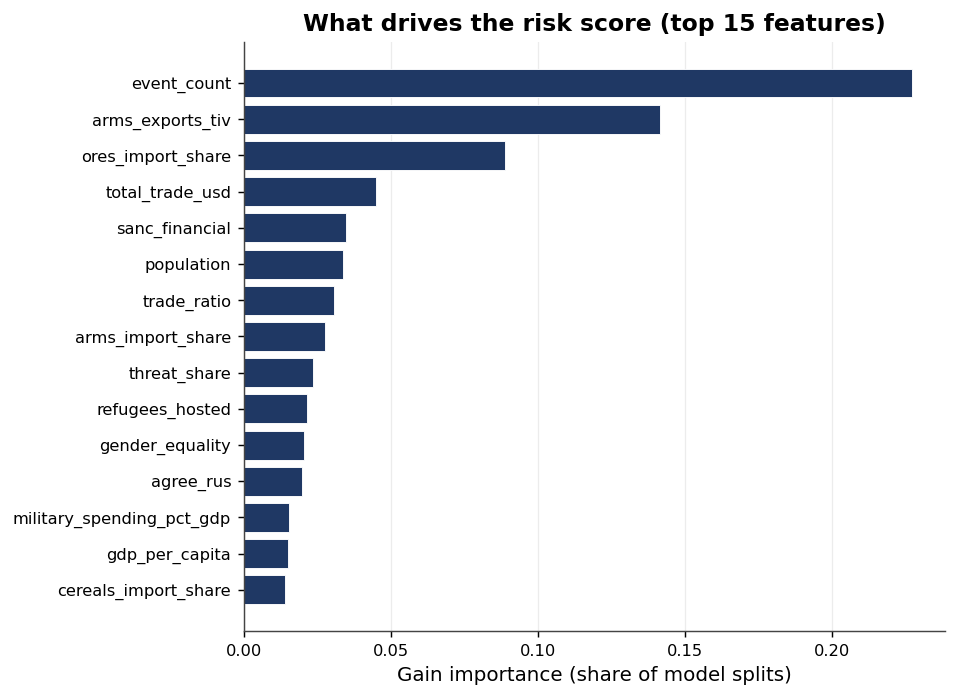

In [5]:
final = xgb.XGBRegressor(**PARAMS).fit(X, y)
gain = pd.Series(final.feature_importances_, index=features).sort_values(ascending=False)

hold = lab.year == 2024
mdl_h = xgb.XGBRegressor(**PARAMS).fit(lab[features][(~hold).values], lab['y'][(~hold).values])
perm = permutation_importance(mdl_h, lab[features][hold.values], lab['y'][hold.values],
                              n_repeats=20, random_state=42)
perm = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
print('Top 12 by GAIN:');                  print(gain.head(12).round(3).to_string())
print('\nTop 12 by PERMUTATION (2024 holdout):'); print(perm.head(12).round(3).to_string())

fig, ax = plt.subplots(figsize=(7.5, 5.5))
top = gain.head(15)[::-1]
ax.barh(range(len(top)), top.values, color=NAVY, edgecolor='white', linewidth=.5)
ax.set_yticks(range(len(top))); ax.set_yticklabels([f.replace('gdelt_', '') for f in top.index], fontsize=9)
ax.set_xlabel('Gain importance (share of model splits)')
ax.set_title('What drives the risk score (top 15 features)')
ax.grid(axis='y', visible=False)
fig.tight_layout(); plt.show()

GDELT news-event volume leads, then arms transfers and trade scale. Sanctions, refugees, and governance act as modifiers. No single feature dominates, so the score is genuinely multi-source.

## 4. Score all 247 countries

The final model scores every country-year, including the 203 with no official GPR, the core deliverable.

In [6]:
M['risk_score'] = np.expm1(final.predict(M[features]))
out = M[['iso3','country','region','income_group','year','gpr','risk_score']].copy()
out.to_csv(str(ROOT / "data/processed/risk_scores_v1.csv"), index=False)

latest = out[out.year==2024].sort_values('risk_score', ascending=False)
print('=== v1 risk score, 2024 — TOP 15 (incl. unlabeled predictions) ===')
print(latest.head(15)[['iso3','country','gpr','risk_score']].to_string(index=False))
print('\n=== BOTTOM 8 ===')
print(latest.tail(8)[['iso3','country','gpr','risk_score']].to_string(index=False))
print('\nSaved risk_scores_v1.csv |', out.shape[0], 'country-years scored')

=== v1 risk score, 2024 — TOP 15 (incl. unlabeled predictions) ===
iso3            country      gpr  risk_score
 USA      United States 3.147449    3.116783
 ISR             Israel 1.917257    1.943534
 RUS Russian Federation 1.624308    1.660971
 GBR     United Kingdom 1.515734    1.507338
 UKR            Ukraine 1.407974    1.389144
 CHN              China 0.871815    0.874779
 FRA             France 0.677276    0.658300
 DEU            Germany 0.557179    0.573458
 EGY   Egypt, Arab Rep. 0.561986    0.536836
 LBN            Lebanon      NaN    0.458909
 IRN Iran, Islamic Rep.      NaN    0.361142
 KOR        Korea, Rep. 0.338295    0.343768
 TUR            Turkiye 0.318542    0.304357
 YEM        Yemen, Rep.      NaN    0.293333
 PAK           Pakistan      NaN    0.280687

=== BOTTOM 8 ===
iso3   country      gpr  risk_score
 NPL     Nepal      NaN    0.031528
 LBR   Liberia      NaN    0.031283
 PER      Peru 0.027667    0.028414
 HND  Honduras      NaN    0.022716
 PRT  Portugal 

### 4a. Risk map (paper figure)

The deliverable in one view: predicted 2024 risk for all 247 countries, including the 203 with no official GPR.

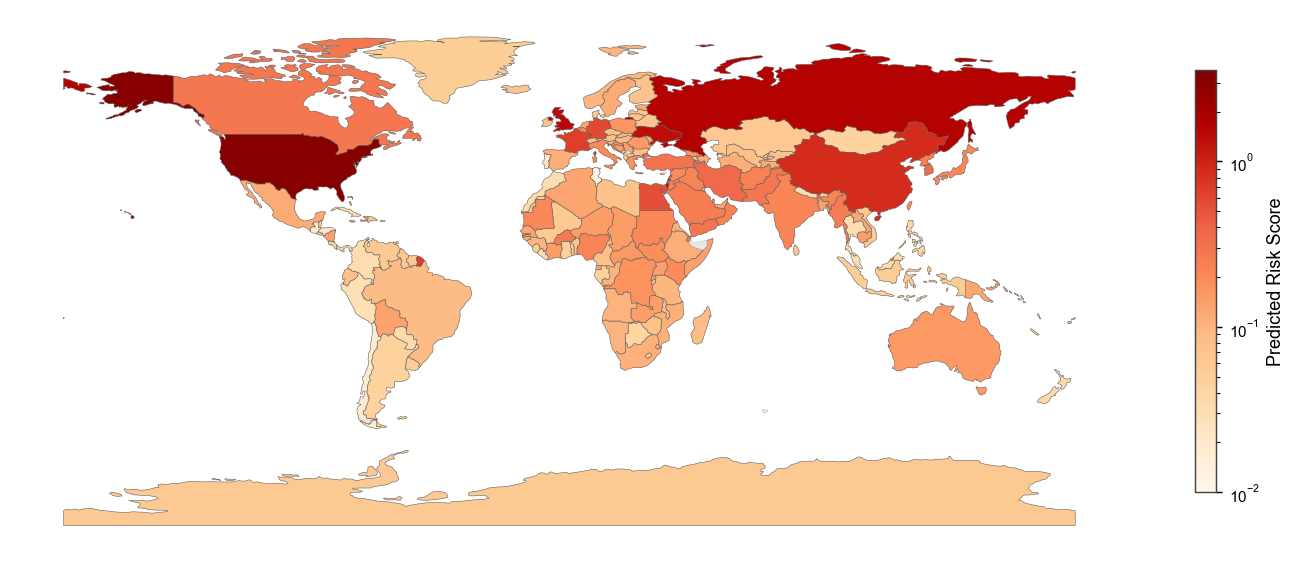

saved /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/reports/proposal/figures/risk_map_2024.png


In [18]:
import os
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# APA figure style: sans-serif font, no embedded title/caption
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
})

FIG_DIR = ROOT / "reports/proposal/figures"
os.makedirs(FIG_DIR, exist_ok=True)

world = gpd.read_file(str(ROOT / "data/external/geodata/ne_110m_admin_0_countries.geojson"))[['ISO_A3_EH', 'geometry']]
d2024 = out[out.year == 2024][['iso3', 'risk_score']]
m = world.merge(d2024, left_on='ISO_A3_EH', right_on='iso3', how='left')

pos = out.risk_score[out.risk_score > 0]
vmin, vmax = max(pos.min(), 0.01), out.risk_score.max()

fig, ax = plt.subplots(figsize=(11, 6.2))

m.plot(
    column='risk_score', ax=ax, cmap='OrRd',
    norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
    edgecolor='#5c5c5c', linewidth=0.3, legend=True,
    legend_kwds={'shrink': 0.55},
    missing_kwds={'color': '#E8E8E8', 'edgecolor': '#bbbbbb', 'linewidth': 0.3}
)

ax.grid(False)
ax.axis('off')

# colorbar is always the last axis matplotlib added — control its text size directly
cax = fig.axes[-1]
cax.set_ylabel('Predicted Risk Score', fontsize=10)
cax.tick_params(labelsize=8.5)

fig.tight_layout()
fig.savefig(str(FIG_DIR / 'risk_map_2024.png'), dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print('saved', FIG_DIR / 'risk_map_2024.png')

## 5. Model selection: three methods compared

Same features and same two validation schemes for XGBoost, Random Forest, and ElasticNet, plus a predict-the-mean baseline.

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor

def make_model(name):
    if name == 'RandomForest': return make_pipeline(SimpleImputer(strategy='median'),
                                    RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3,
                                                          random_state=42, n_jobs=-1))
    if name == 'ElasticNet':   return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                                    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))
    return DummyRegressor(strategy='mean')

def eval_groupkfold(name):
    oof_ = np.zeros(len(lab))
    for tr, te in GroupKFold(5).split(X, y, grp):
        oof_[te] = make_model(name).fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
    p = np.expm1(oof_); a = lab.gpr.values
    return spearmanr(a, p).statistic, mean_absolute_error(a, p)

def eval_expanding(name):
    A, P = [], []
    for t_ in years:
        if len([z for z in years if z < t_]) < MIN_TRAIN_YEARS: continue
        trm, tem = lab.year < t_, lab.year == t_
        pr = np.expm1(make_model(name).fit(lab[features][trm.values], lab['y'][trm.values]).predict(lab[features][tem.values]))
        A.extend(lab.gpr[tem.values].values); P.extend(pr)
    return spearmanr(A, P).statistic, mean_absolute_error(A, P)

# XGBoost reuses the numbers already computed in sections 1 and 2 (no refit)
rows = [{'model': 'XGBoost', 'countries_Spearman': rho, 'countries_MAE': mae_raw,
         'years_Spearman': pool_sp, 'years_MAE': pool_mae}]
for nm in ['RandomForest', 'ElasticNet']:
    gk, ew = eval_groupkfold(nm), eval_expanding(nm)
    rows.append({'model': nm, 'countries_Spearman': gk[0], 'countries_MAE': gk[1],
                 'years_Spearman': ew[0], 'years_MAE': ew[1]})
bench = pd.DataFrame(rows)
print('=== Three models, same validation ==='); print(bench.round(3).to_string(index=False))

base_mae_c = eval_groupkfold('Baseline')[1]
base_mae_y = eval_expanding('Baseline')[1]
print(f'Baseline (predict mean) MAE | unseen countries {base_mae_c:.3f} | unseen years {base_mae_y:.3f}')

=== Three models, same validation ===
       model  countries_Spearman  countries_MAE  years_Spearman  years_MAE
     XGBoost               0.807          0.159           0.910      0.109
RandomForest               0.744          0.177           0.906      0.119
  ElasticNet               0.639          0.241           0.845      0.139
Baseline (predict mean) MAE | unseen countries 0.274 | unseen years 0.275


In [9]:
comp = bench.rename(columns={
            'model': 'Model',
            'countries_Spearman': 'Spearman (unseen countries)',
            'years_Spearman':     'Spearman (unseen years)',
            'countries_MAE':      'MAE (unseen countries)',
            'years_MAE':          'MAE (unseen years)'})[
        ['Model', 'Spearman (unseen countries)', 'Spearman (unseen years)',
         'MAE (unseen countries)', 'MAE (unseen years)']].copy()
base_row = pd.DataFrame([{'Model': 'Baseline (predict mean)',
                          'Spearman (unseen countries)': np.nan, 'Spearman (unseen years)': np.nan,
                          'MAE (unseen countries)': base_mae_c, 'MAE (unseen years)': base_mae_y}])
comp = pd.concat([comp, base_row], ignore_index=True)
comp = comp.sort_values('Spearman (unseen countries)', ascending=False, na_position='last').round(3).reset_index(drop=True)
comp_out = comp.fillna('\u2014')
xlsx_path = str(ROOT / "data/processed/model_comparison.xlsx")
comp_out.to_excel(xlsx_path, index=False, sheet_name='Model comparison')
print('Winner:', comp_out.iloc[0]['Model'])
print(comp_out.to_string(index=False))
print('\nSaved', xlsx_path)

Winner: XGBoost
                  Model Spearman (unseen countries) Spearman (unseen years)  MAE (unseen countries)  MAE (unseen years)
                XGBoost                       0.807                    0.91                   0.159               0.109
           RandomForest                       0.744                   0.906                   0.177               0.119
             ElasticNet                       0.639                   0.845                   0.241               0.139
Baseline (predict mean)                           —                       —                   0.274               0.275

Saved /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/processed/model_comparison.xlsx


XGBoost wins both tests, decisively on the hard one. On unseen countries it scores 0.81 against 0.74 (Random Forest) and 0.64 (ElasticNet). This justifies XGBoost by a like-for-like comparison, not assertion.

## 6. Full 2024 forecast: all 44 countries

Every labeled country, actual versus the model's 2024 forecast (trained only on 2015 to 2023)

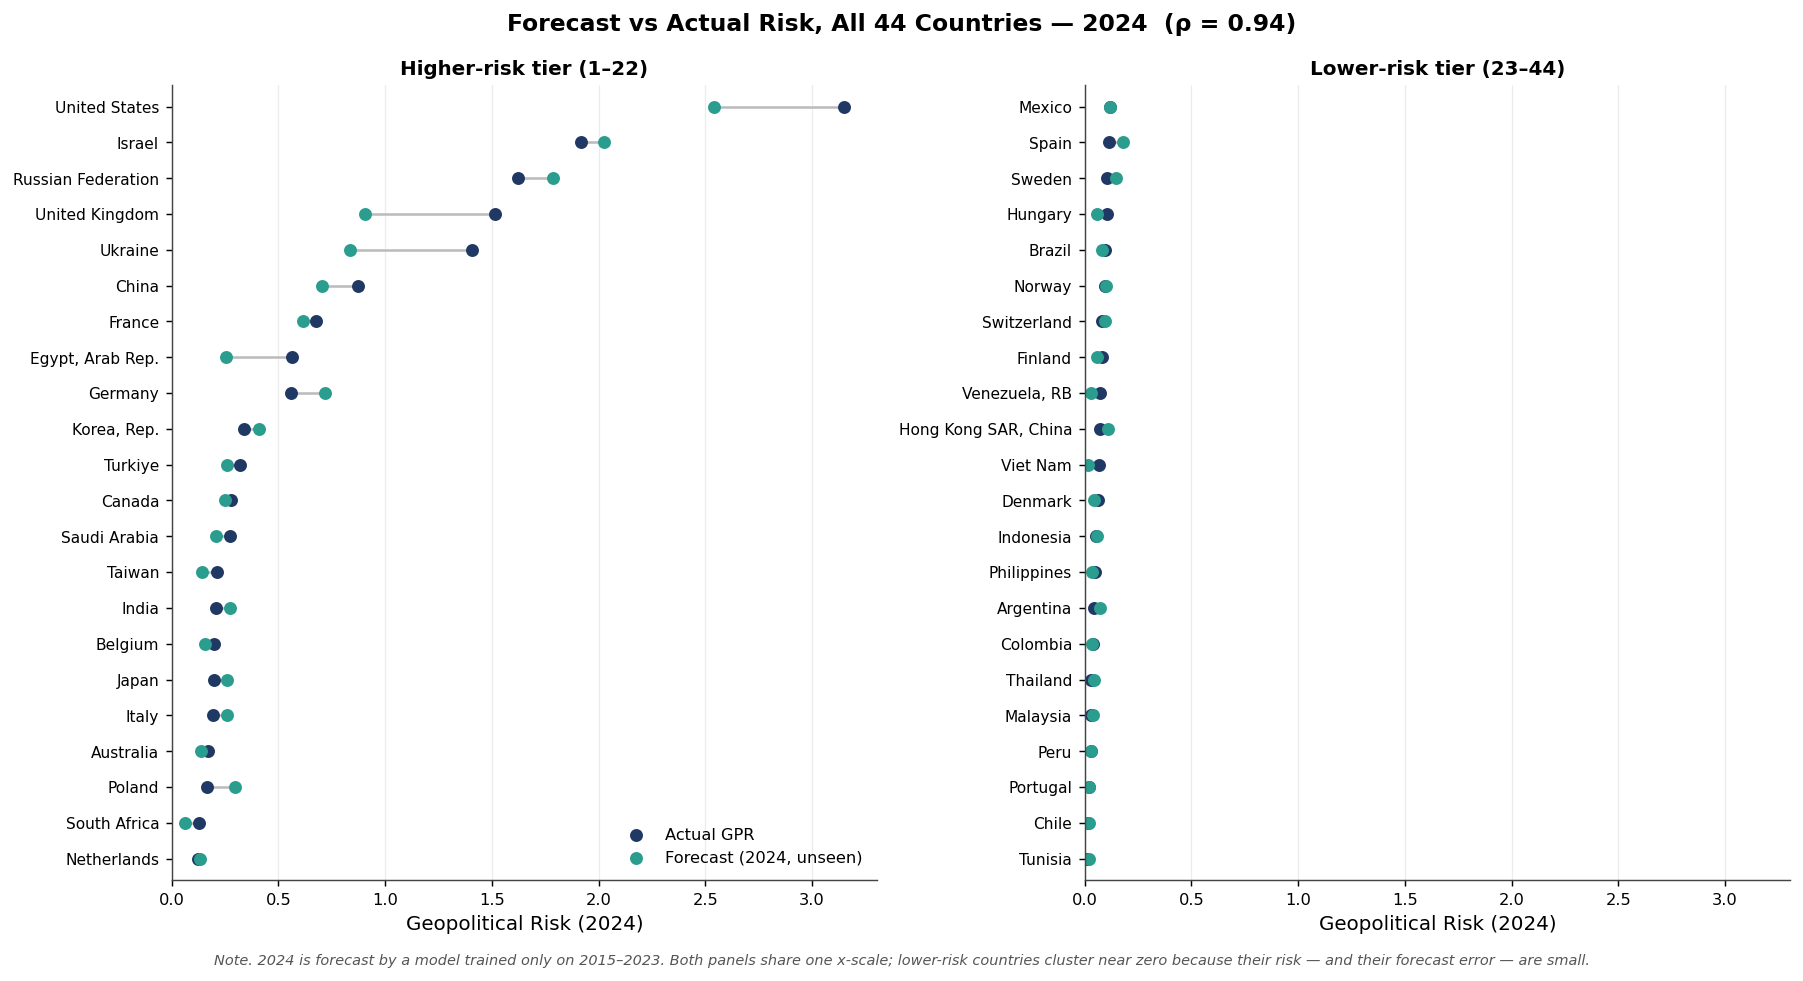

In [10]:
d44 = ew_pool[ew_pool.year == 2024].sort_values('actual', ascending=False).reset_index(drop=True)
half = (len(d44) + 1) // 2
sp = spearmanr(d44.actual, d44.pred).statistic
xmax = max(d44.actual.max(), d44.pred.max()) * 1.05
fig, axes = plt.subplots(1, 2, figsize=(14, 7.4))
for ax, part, sub in zip(axes, [d44.iloc[:half], d44.iloc[half:]],
                         ['Higher-risk tier (1\u201322)', 'Lower-risk tier (23\u201344)']):
    part = part.iloc[::-1]
    yy = np.arange(len(part))
    ax.hlines(yy, part.pred, part.actual, color=GREY, lw=1.4, zorder=1)
    ax.scatter(part.actual, yy, color=NAVY, s=38, label='Actual GPR', zorder=2)
    ax.scatter(part.pred,   yy, color=TEAL, s=38, label='Forecast (2024, unseen)', zorder=2)
    ax.set_yticks(yy); ax.set_yticklabels(part.country, fontsize=8.5)
    ax.set_ylim(-0.6, len(part) - 0.4); ax.set_xlim(0, xmax)
    ax.set_xlabel('Geopolitical Risk (2024)')
    ax.set_title(sub, fontsize=11)
    ax.grid(axis='y', visible=False)
axes[0].legend(loc='lower right', fontsize=9)
fig.suptitle(f'Forecast vs Actual Risk, All 44 Countries \u2014 2024  (\u03c1 = {sp:.2f})',
             fontsize=13, fontweight='bold')
fig.text(0.5, -0.01,
         'Note. 2024 is forecast by a model trained only on 2015\u20132023. Both panels share one x-scale; '
         'lower-risk countries cluster near zero because their risk \u2014 and their forecast error \u2014 are small.',
         ha='center', fontsize=8, style='italic', color='#555')
fig.tight_layout(); plt.show()

Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.